In [8]:
# =====================================================================
# STEP 1 — Mount Drive, locate files, load and profile the data
# =====================================================================
import pandas as pd, numpy as np
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# --- locate the project folder ------------------------------------------------
CANDIDATES = [
    Path("/content/drive/MyDrive/freight_project"),
    Path("/content/freight_project"),
]
BASE = next((p for p in CANDIDATES if p.is_dir()), None)

if BASE is None:                      # fall back to searching Drive
    for p in Path("/content/drive").rglob("*.csv"):
        if "train" in p.stem.lower().replace("-", "_"):
            BASE = p.parent
            break

if BASE is None:
    raise SystemExit("Could not find the project folder — check the folder name in Drive.")

print("BASE =", BASE)
print("files found:")
for p in sorted(BASE.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(BASE), f"({p.stat().st_size/1e6:.2f} MB)")

# --- resolve the four CSVs (works with hyphens or underscores) ----------------
def find(keys, exclude=()):
    for p in sorted(BASE.rglob("*.csv")):
        s = p.stem.lower().replace("-", "_")
        if all(k in s for k in keys) and not any(x in s for x in exclude):
            return p
    raise FileNotFoundError(f"no csv matching {keys} under {BASE}")

TRAIN    = find(["train"])
VALID    = find(["validation"], exclude=["template", "predictions"])
TEMPLATE = find(["template"])
DEC      = find(["december"])
print("\nTRAIN:", TRAIN.name, "| VALID:", VALID.name,
      "| TEMPLATE:", TEMPLATE.name, "| DEC:", DEC.name)

# --- load --------------------------------------------------------------------
train = pd.read_csv(TRAIN, parse_dates=["date"])
valid = pd.read_csv(VALID, parse_dates=["date"])
dec   = pd.read_csv(DEC,   parse_dates=["date"])

print("\ntrain:", train.shape, "| valid:", valid.shape, "| december:", dec.shape)

# --- what the December chart is missing ---------------------------------------
missing_in_dec = sorted(set(train.columns) - set(dec.columns) - {"posted_rate", "load_id"})
print("\ncolumns in train but NOT available for the December chart:")
print(" ", missing_in_dec)

# --- profile -----------------------------------------------------------------
print("\n--- dtypes ---");                print(train.dtypes)
print("\n--- missing values (train) ---");  print(train.isna().sum()[lambda s: s > 0])
print("--- missing values (valid) ---");    print(valid.isna().sum()[lambda s: s > 0])
print("\n--- duplicates --- load_id:", train.load_id.duplicated().sum(),
      "| full rows:", train.duplicated().sum())

print("\n--- date coverage ---")
print("train:", train.date.min().date(), "→", train.date.max().date(),
      "|", train.date.nunique(), "distinct days")
print("valid:", valid.date.min().date(), "→", valid.date.max().date(),
      "|", valid.date.nunique(), "distinct days")
print("overlap:", len(set(train.date) & set(valid.date)), "days")

num = ["distance", "weight", "market_index", "quote_signal", "posted_rate"]
print("\n--- numeric summary (train) ---")
print(train[num].describe().T)

print("\n--- suspicious values ---")
print("negative weight rows:", (train.weight < 0).sum())
rpm = train.posted_rate / train.distance
print("rate per mile quantiles:")
print(rpm.quantile([0.001, 0.01, 0.50, 0.99, 0.999]).round(3).to_string())
print("rows with rate/mile > 5:", (rpm > 5).sum())

print("\n--- categoricals ---")
print(train.equipment.value_counts())
print("pickup cities:", train.pickup.nunique(),
      "| delivery cities:", train.delivery.nunique())
print("equipment values in valid but not train:",
      set(valid.equipment) - set(train.equipment))
print("cities in valid but not train:",
      (set(valid.pickup) | set(valid.delivery)) - (set(train.pickup) | set(train.delivery)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE = /content/drive/MyDrive/freight_project
files found:
   december-chart-inputs.csv (0.00 MB)
   december_chart_inputs_completed.csv (0.00 MB)
   freight-rate-ml-assessment.pdf (0.12 MB)
   readme.md (0.00 MB)
   requirements.txt (0.00 MB)
   score.py (0.01 MB)
   train-test.csv (5.96 MB)
   validation-predictions-template.csv (0.13 MB)
   validation.csv (1.39 MB)
   validation_predictions.csv (0.34 MB)

TRAIN: train-test.csv | VALID: validation.csv | TEMPLATE: validation-predictions-template.csv | DEC: december-chart-inputs.csv

train: (48000, 14) | valid: (12000, 13) | december: (31, 7)

columns in train but NOT available for the December chart:
  ['delivery_lat', 'delivery_lon', 'market_index', 'pickup_lat', 'pickup_lon', 'quote_signal']

--- dtypes ---
load_id                 object
pickup                  object
delivery                object
pickup_

In [11]:
# =====================================================================
# STEP 2b — Are the 677 rows corruption or real variation?
# =====================================================================
o = train.loc[train.is_outlier].copy()
o["factor"] = np.exp(o.log_resid)          # multiplier applied to the true rate

print("flagged:", len(o), "| inflated:", (o.log_resid > 0).sum(),
      "| deflated:", (o.log_resid < 0).sum())

print("\nmultiplier distribution:")
h, e = np.histogram(o.factor, bins=np.arange(0, 7.5, 0.25))
for cnt, ed in zip(h, e):
    if cnt or (0.4 < ed < 2.1):
        print(f"  x{ed:4.2f} {cnt:4d} " + "#" * min(cnt, 60))

cl = train.loc[~train.is_outlier]
print("\nno feature signature? compare the two groups:")
for col in ["distance", "weight", "posted_rate"]:
    print(f"  {col:12s} clean median {cl[col].median():9.1f} | flagged {o[col].median():9.1f}")
print("\n  equipment share (%):")
print(pd.concat([cl.equipment.value_counts(normalize=True) * 100,
                 o.equipment.value_counts(normalize=True) * 100],
                axis=1, keys=["clean", "flagged"]).round(1).to_string())
print("\n  flagged rows per month:")
print(o.groupby(o.date.dt.month).size().to_string())

# ---- close the leakage hole: refit the rule inside a training fold only ------
CUT = pd.Timestamp("2025-09-01")          # provisional; Step 4 sets the real split
fit_part = train[train.date < CUT]
ldf, lrf = np.log(fit_part.distance).values, np.log(fit_part.posted_rate).values
keep = np.ones(len(fit_part), bool)
for _ in range(5):
    cf   = np.polyfit(ldf[keep], lrf[keep], 1)
    rf   = lrf - np.polyval(cf, ldf)
    madf = 1.4826 * np.median(np.abs(rf - np.median(rf)))
    keep = np.abs(rf - np.median(rf)) < 5 * madf
print(f"\nfold-only fit: {cf[1]:.3f} + {cf[0]:.3f}*log(d)   (full-data fit was 1.651 + 0.871)")
resid_all = np.log(train.posted_rate) - np.polyval(cf, np.log(train.distance))
print("outliers flagged by fold-only rule:", (resid_all.abs() > 0.5).sum(),
      "| by full-data rule:", train.is_outlier.sum(),
      "| disagreements:", ((resid_all.abs() > 0.5) != train.is_outlier).sum())

flagged: 677 | inflated: 340 | deflated: 337

multiplier distribution:
  x0.00  137 ############################################################
  x0.25  199 ############################################################
  x0.50    1 #
  x0.75    0 
  x1.00    0 
  x1.25    0 
  x1.50    0 
  x1.75    0 
  x2.00    9 #########
  x2.25   25 #########################
  x2.50   40 ########################################
  x2.75   33 #################################
  x3.00   44 ############################################
  x3.25   41 #########################################
  x3.50   17 #################
  x3.75   28 ############################
  x4.00   14 ##############
  x4.25   31 ###############################
  x4.50   27 ###########################
  x4.75   16 ################
  x5.00    7 #######
  x5.25    4 ####
  x5.50    4 ####

no feature signature? compare the two groups:
  distance     clean median     954.1 | flagged     874.4
  weight       clean median   31494.0 | f

In [10]:
# =====================================================================
# STEP 3 — How is the rate actually formed?
# =====================================================================
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression

d = train_clean.copy()
d["lr"] = np.log(d.posted_rate)

def block(cols, label):
    X = np.column_stack(cols)
    m = LinearRegression().fit(X, d.lr)
    p = m.predict(X)
    r2 = 1 - ((d.lr - p) ** 2).sum() / ((d.lr - d.lr.mean()) ** 2).sum()
    print(f"{label:42s} R2={r2:.5f}  resid_sd={np.std(d.lr - p):.5f}")
    return m, d.lr - p

ld     = np.log(d.distance)
reefer = (d.equipment == "Reefer").astype(float)
flat   = (d.equipment == "Flatbed").astype(float)
lmkt   = np.log(d.market_index_daily)
lw     = np.log(d.weight)
lq     = np.log(d.quote_signal)

block([ld],                              "log distance")
block([ld, reefer, flat],                "+ equipment")
block([ld, reefer, flat, lmkt],          "+ log market index")
m, res = block([ld, reefer, flat, lmkt, lw], "+ log weight")
block([ld, reefer, flat, lmkt, lw, lq],  "+ log quote_signal  (does it earn it?)")
print("\nelasticities [ld, reefer, flat, lmkt, lw]:", np.round(m.coef_, 4),
      " intercept:", round(m.intercept_, 4))

# ---- geography ---------------------------------------------------------------
G = d[["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]].values
g = LinearRegression().fit(G, res)
res_geo = res - g.predict(G)
print(f"\nlat/lon explains {g.score(G, res)*100:.1f}% of the remaining residual variance")
print("residual sd: before geo %.5f -> after %.5f" % (res.std(), res_geo.std()))
d["res"] = res
print("\nlowest-priced origins:");  print(d.groupby("pickup").res.mean().nsmallest(4).round(4).to_string())
print("highest-priced origins:");   print(d.groupby("pickup").res.mean().nlargest(4).round(4).to_string())

# ---- the temporal structure --------------------------------------------------
d["quarter"] = d.date.dt.quarter
d["doq"]     = (d.date - d.date.dt.to_period("Q").dt.start_time).dt.days
print("\nmean residual by week-of-quarter (columns = quarter):")
print(d.groupby(["quarter", d.doq // 7]).res.mean().unstack(0).round(4).to_string())
print("\nquarter level (first 31 days of each quarter):")
lvl = d.loc[d.doq < 31].groupby("quarter").res.mean()
print(lvl.round(4).to_string())
print("level step per quarter:", np.round(np.diff(lvl.values), 4))

# ---- can the validation months be reached? ----------------------------------
print("\nday-of-quarter range in TRAIN by quarter:")
print(d.groupby("quarter").doq.agg(["min", "max"]).to_string())
vq = valid.assign(quarter=valid.date.dt.quarter,
                  doq=(valid.date - valid.date.dt.to_period("Q").dt.start_time).dt.days)
print("\nday-of-quarter range needed for VALIDATION:")
print(vq.groupby("quarter").doq.agg(["min", "max"]).to_string())

log distance                               R2=0.98708  resid_sd=0.07378
+ equipment                                R2=0.99384  resid_sd=0.05093
+ log market index                         R2=0.99494  resid_sd=0.04616
+ log weight                               R2=0.99622  resid_sd=0.03991
+ log quote_signal  (does it earn it?)     R2=0.99624  resid_sd=0.03978

elasticities [ld, reefer, flat, lmkt, lw]: [0.871  0.1217 0.08   0.1397 0.0812]  intercept: 0.7591

lat/lon explains 27.7% of the remaining residual variance
residual sd: before geo 0.03991 -> after 0.03393

lowest-priced origins:
pickup
Syracuse   -0.0368
Buffalo    -0.0329
Detroit    -0.0312
Toledo     -0.0282
highest-priced origins:
pickup
Oklahoma City    0.0277
Dallas           0.0274
Lubbock          0.0256
Houston          0.0247

mean residual by week-of-quarter (columns = quarter):
quarter       1       2       3       4
doq                                    
0       -0.0333 -0.0221  0.0026  0.0206
1       -0.0315 -0.0200

In [12]:
# =====================================================================
# STEP 4 — Split design, metrics, and a reference baseline
# =====================================================================
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression

# ---- feature builder (extended in Step 5) -----------------------------------
def make_X(df):
    return pd.DataFrame({
        "log_distance": np.log(df.distance),
        "log_weight":   np.log(df.weight),
        "log_market":   np.log(df.market_index_daily),
        "reefer":       (df.equipment == "Reefer").astype(float),
        "flatbed":      (df.equipment == "Flatbed").astype(float),
        "pickup_lat":   df.pickup_lat,  "pickup_lon":   df.pickup_lon,
        "delivery_lat": df.delivery_lat,"delivery_lon": df.delivery_lon,
    }, index=df.index)

# ---- metrics: dollars, and always reported twice ----------------------------
def evaluate(actual, pred, is_outlier, label=""):
    a, p, o = np.asarray(actual), np.asarray(pred), np.asarray(is_outlier)
    def m(mask):
        e = p[mask] - a[mask]
        return (np.sqrt((e**2).mean()), np.abs(e).mean(),
                np.mean(np.abs(e) / a[mask]) * 100)
    all_r, clean_r = m(np.ones(len(a), bool)), m(~o)
    print(f"{label:24s} ALL  RMSE ${all_r[0]:7.0f}  MAE ${all_r[1]:6.0f}  MAPE {all_r[2]:5.2f}%"
          f"   | CLEAN  MAE ${clean_r[1]:6.0f}  MAPE {clean_r[2]:5.2f}%")
    return {"mae_all": all_r[1], "mape_all": all_r[2],
            "mae_clean": clean_r[1], "mape_clean": clean_r[2]}

# ---- the four folds ---------------------------------------------------------
T = pd.Timestamp
FOLDS = {
    "A  Jan-Apr -> May-Jun": (T("2025-01-01"), T("2025-04-30"), T("2025-05-01"), T("2025-06-30")),
    "B  Jan-Jun -> Jul-Aug": (T("2025-01-01"), T("2025-06-30"), T("2025-07-01"), T("2025-08-31")),
    "C  Jan-Aug -> Sep-Oct": (T("2025-01-01"), T("2025-08-31"), T("2025-09-01"), T("2025-10-31")),
    "D  Jan-Jul -> Sep (Dec analogue)":
                             (T("2025-01-01"), T("2025-07-31"), T("2025-09-01"), T("2025-09-30")),
}

def run_folds(fit_predict, name):
    print(f"\n===== {name} =====")
    out = {}
    for fold, (tr0, tr1, va0, va1) in FOLDS.items():
        trm = train.date.between(tr0, tr1)
        vam = train.date.between(va0, va1)
        # CRITICAL: outliers removed from TRAINING only, never from the held-out side
        tr_df = train.loc[trm & ~train.is_outlier]
        va_df = train.loc[vam]
        pred  = fit_predict(tr_df, va_df)
        out[fold] = evaluate(va_df.posted_rate, pred, va_df.is_outlier, fold)
    return out

# ---- baseline: the Step-3 linear model, deliberately WITHOUT time features ---
def baseline(tr_df, va_df):
    m = LinearRegression().fit(make_X(tr_df), np.log(tr_df.posted_rate))
    return np.exp(m.predict(make_X(va_df)))

res_baseline = run_folds(baseline, "BASELINE (no time features)")

# ---- how much of the error is the missing time structure? -------------------
print("\nmean signed log error per fold (positive = under-predicting):")
for fold, (tr0, tr1, va0, va1) in FOLDS.items():
    trm = train.date.between(tr0, tr1); vam = train.date.between(va0, va1)
    tr_df = train.loc[trm & ~train.is_outlier]; va_df = train.loc[vam & ~train.is_outlier]
    m = LinearRegression().fit(make_X(tr_df), np.log(tr_df.posted_rate))
    bias = (np.log(va_df.posted_rate) - m.predict(make_X(va_df))).mean()
    print(f"  {fold:34s} {bias:+.4f}   (= {np.exp(bias)-1:+.2%} on rate)")


===== BASELINE (no time features) =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    638  MAE $   122  MAPE  5.01%   | CLEAN  MAE $    69  MAPE  2.76%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    626  MAE $   110  MAPE  4.72%   | CLEAN  MAE $    58  MAPE  2.49%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    652  MAE $   166  MAPE  7.03%   | CLEAN  MAE $   111  MAPE  4.64%
D  Jan-Jul -> Sep (Dec analogue) ALL  RMSE $    646  MAE $   191  MAPE  7.74%   | CLEAN  MAE $   140  MAPE  5.84%

mean signed log error per fold (positive = under-predicting):
  A  Jan-Apr -> May-Jun              +0.0177   (= +1.79% on rate)
  B  Jan-Jun -> Jul-Aug              +0.0157   (= +1.58% on rate)
  C  Jan-Aug -> Sep-Oct              +0.0466   (= +4.77% on rate)
  D  Jan-Jul -> Sep (Dec analogue)   +0.0600   (= +6.18% on rate)


In [13]:
# =====================================================================
# STEP 5 — Time features, and two competing architectures
# =====================================================================
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

ORIGIN = pd.Timestamp("2025-01-01")

def add_time(df):
    df = df.copy()
    qstart      = df.date.dt.to_period("Q").dt.start_time
    df["doq"]   = (df.date - qstart).dt.days          # 0..91  position in quarter
    df["quarter"] = df.date.dt.quarter
    df["t"]     = (df.date - ORIGIN).dt.days          # global linear trend
    df["dow"]   = df.date.dt.dayofweek
    df["dom"]   = df.date.dt.day
    return df

train = add_time(train); valid = add_time(valid)

# ---- linear stage: everything that must extrapolate --------------------------
def make_X_lin(df):
    x = df.doq.values / 91.0
    return pd.DataFrame({
        "log_distance": np.log(df.distance), "log_weight": np.log(df.weight),
        "log_market":   np.log(df.market_index_daily),
        "reefer": (df.equipment == "Reefer").astype(float),
        "flatbed": (df.equipment == "Flatbed").astype(float),
        "pickup_lat": df.pickup_lat, "pickup_lon": df.pickup_lon,
        "delivery_lat": df.delivery_lat, "delivery_lon": df.delivery_lon,
        "trend": df.t / 365.0,                      # level drift across quarters
        "doq1": x, "doq2": x**2, "doq3": x**3,      # within-quarter ramp shape
    }, index=df.index)

# ---- tree stage: features for the residual ----------------------------------
TREE_COLS = ["log_distance", "log_weight", "log_market", "eq", "doq", "dow",
             "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]

def make_X_tree(df, with_quarter=False):
    out = pd.DataFrame({
        "log_distance": np.log(df.distance), "log_weight": np.log(df.weight),
        "log_market":   np.log(df.market_index_daily),
        "eq": df.equipment.map({"Dry Van": 0, "Reefer": 1, "Flatbed": 2}).astype(float),
        "doq": df.doq.astype(float), "dow": df.dow.astype(float),
        "pickup_lat": df.pickup_lat, "pickup_lon": df.pickup_lon,
        "delivery_lat": df.delivery_lat, "delivery_lon": df.delivery_lon,
    }, index=df.index)
    if with_quarter:
        out["quarter"] = df.quarter.astype(float)
        out["t"] = df.t.astype(float)
    return out

# ---- candidate 1: pure GBM (the trap) ---------------------------------------
def pure_gbm(tr_df, va_df):
    m = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                      max_leaf_nodes=31, min_samples_leaf=40,
                                      l2_regularization=1.0, random_state=0)
    m.fit(make_X_tree(tr_df, True), np.log(tr_df.posted_rate))
    return np.exp(m.predict(make_X_tree(va_df, True)))

# ---- candidate 2: additive hybrid -------------------------------------------
def hybrid(tr_df, va_df):
    lin = LinearRegression().fit(make_X_lin(tr_df), np.log(tr_df.posted_rate))
    r   = np.log(tr_df.posted_rate) - lin.predict(make_X_lin(tr_df))
    gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                        max_leaf_nodes=31, min_samples_leaf=40,
                                        l2_regularization=1.0, random_state=0)
    gbm.fit(make_X_tree(tr_df), r)
    return np.exp(lin.predict(make_X_lin(va_df)) + gbm.predict(make_X_tree(va_df)))

# ---- linear stage alone, to isolate what the tree adds ----------------------
def linear_only(tr_df, va_df):
    lin = LinearRegression().fit(make_X_lin(tr_df), np.log(tr_df.posted_rate))
    return np.exp(lin.predict(make_X_lin(va_df)))

res_lin    = run_folds(linear_only, "LINEAR + time features")
res_gbm    = run_folds(pure_gbm,    "PURE GBM (quarter + t as features)")
res_hybrid = run_folds(hybrid,      "HYBRID (linear + GBM on residual)")

# ---- the bias check that matters -------------------------------------------
print("\nsigned log bias per fold (positive = under-predicting):")
for name, fp in [("linear", linear_only), ("pure gbm", pure_gbm), ("hybrid", hybrid)]:
    row = []
    for fold, (tr0, tr1, va0, va1) in FOLDS.items():
        tr_df = train.loc[train.date.between(tr0, tr1) & ~train.is_outlier]
        va_df = train.loc[train.date.between(va0, va1) & ~train.is_outlier]
        bias  = (np.log(va_df.posted_rate) - np.log(fp(tr_df, va_df))).mean()
        row.append(f"{bias:+.4f}")
    print(f"  {name:9s} " + "  ".join(row))


===== LINEAR + time features =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    630  MAE $   105  MAPE  4.39%   | CLEAN  MAE $    51  MAPE  2.12%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    620  MAE $   105  MAPE  4.68%   | CLEAN  MAE $    53  MAPE  2.38%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    632  MAE $   105  MAPE  4.69%   | CLEAN  MAE $    49  MAPE  2.17%
D  Jan-Jul -> Sep (Dec analogue) ALL  RMSE $    613  MAE $   101  MAPE  4.27%   | CLEAN  MAE $    50  MAPE  2.21%

===== PURE GBM (quarter + t as features) =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    634  MAE $   109  MAPE  4.56%   | CLEAN  MAE $    56  MAPE  2.32%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    619  MAE $   104  MAPE  4.61%   | CLEAN  MAE $    52  MAPE  2.30%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    634  MAE $   105  MAPE  4.57%   | CLEAN  MAE $    49  MAPE  2.08%
D  Jan-Jul -> Sep (Dec analogue) ALL  RMSE $    614  MAE $    91  MAPE  3.78%   | CLEAN  MAE $    40  MAPE  1.73%

===== HYBRID (linear + GBM on residual) =====
A  Ja

In [14]:
# =====================================================================
# STEP 6 — Refining the hybrid; testing quote_signal properly
# =====================================================================
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

def make_X_lin_v2(df, trend="daily", use_quote=False):
    x = df.doq.values / 91.0
    cols = {
        "log_distance": np.log(df.distance), "log_weight": np.log(df.weight),
        "log_market":   np.log(df.market_index_daily),
        "reefer": (df.equipment == "Reefer").astype(float),
        "flatbed": (df.equipment == "Flatbed").astype(float),
        "pickup_lat": df.pickup_lat, "pickup_lon": df.pickup_lon,
        "delivery_lat": df.delivery_lat, "delivery_lon": df.delivery_lon,
        "doq1": x, "doq2": x**2, "doq3": x**3,
    }
    # level drift: smooth daily, or stepwise by quarter (no drift inside a quarter)
    cols["trend"] = df.t / 365.0 if trend == "daily" else df.quarter.astype(float)
    if use_quote:
        cols["log_quote"] = np.log(df.quote_signal)
    return pd.DataFrame(cols, index=df.index)

def build_hybrid(trend="daily", recalibrate=False, use_quote=False, recal_days=30):
    def fp(tr_df, va_df):
        Xl = make_X_lin_v2(tr_df, trend, use_quote)
        lin = LinearRegression().fit(Xl, np.log(tr_df.posted_rate))
        r   = np.log(tr_df.posted_rate) - lin.predict(Xl)
        gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                           max_leaf_nodes=31, min_samples_leaf=40,
                                           l2_regularization=1.0, random_state=0)
        gbm.fit(make_X_tree(tr_df), r)

        def logpred(df):
            return (lin.predict(make_X_lin_v2(df, trend, use_quote))
                    + gbm.predict(make_X_tree(df)))

        offset = 0.0
        if recalibrate:                     # zero the bias over the most recent window
            recent = tr_df[tr_df.date > tr_df.date.max() - pd.Timedelta(days=recal_days)]
            offset = (np.log(recent.posted_rate) - logpred(recent)).mean()
        return np.exp(logpred(va_df) + offset)
    return fp

variants = {
    "H1 daily trend (current)":      build_hybrid("daily"),
    "H2 stepwise quarter level":     build_hybrid("quarter"),
    "H3 H1 + recent recalibration":  build_hybrid("daily", recalibrate=True),
    "H4 H1 + quote_signal":          build_hybrid("daily", use_quote=True),
}
results = {name: run_folds(fp, name) for name, fp in variants.items()}

# ---- summary table on the metric that matters ------------------------------
print("\n" + "=" * 78)
print(f"{'variant':32s}" + "".join(f"{k[:1]:>11s}" for k in FOLDS) + "     mean")
for name, r in results.items():
    vals = [r[f]["mape_clean"] for f in FOLDS]
    print(f"{name:32s}" + "".join(f"{v:10.2f}%" for v in vals) + f"{np.mean(vals):9.2f}%")

# ---- what residual scatter are we actually achieving? ---------------------
print("\nachieved log-residual sd on held-out clean rows (fold D):")
tr0, tr1, va0, va1 = FOLDS["D  Jan-Jul -> Sep (Dec analogue)"]
tr_df = train.loc[train.date.between(tr0, tr1) & ~train.is_outlier]
va_df = train.loc[train.date.between(va0, va1) & ~train.is_outlier]
for name, fp in variants.items():
    lr = np.log(va_df.posted_rate) - np.log(fp(tr_df, va_df))
    print(f"  {name:32s} sd={lr.std():.4f}  bias={lr.mean():+.4f}")


===== H1 daily trend (current) =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    628  MAE $    89  MAPE  3.71%   | CLEAN  MAE $    35  MAPE  1.43%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    618  MAE $    95  MAPE  4.13%   | CLEAN  MAE $    42  MAPE  1.82%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    630  MAE $    93  MAPE  4.09%   | CLEAN  MAE $    37  MAPE  1.56%
D  Jan-Jul -> Sep (Dec analogue) ALL  RMSE $    611  MAE $    89  MAPE  3.69%   | CLEAN  MAE $    37  MAPE  1.61%

===== H2 stepwise quarter level =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    628  MAE $    89  MAPE  3.71%   | CLEAN  MAE $    35  MAPE  1.43%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    618  MAE $    94  MAPE  4.11%   | CLEAN  MAE $    42  MAPE  1.81%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    630  MAE $    93  MAPE  4.10%   | CLEAN  MAE $    37  MAPE  1.57%
D  Jan-Jul -> Sep (Dec analogue) ALL  RMSE $    611  MAE $    89  MAPE  3.68%   | CLEAN  MAE $    37  MAPE  1.60%

===== H3 H1 + recent recalibration =====
A  Jan-Apr -> May

In [15]:
# =====================================================================
# STEP 6b — Is the ramp shape misfit at quarter-end? (matters for December)
# =====================================================================
tr0, tr1, va0, va1 = FOLDS["D  Jan-Jul -> Sep (Dec analogue)"]
tr_df = train.loc[train.date.between(tr0, tr1) & ~train.is_outlier]
va_df = train.loc[train.date.between(va0, va1) & ~train.is_outlier]

pred = build_hybrid("daily")(tr_df, va_df)
err  = pd.DataFrame({"doq": va_df.doq.values,
                     "e": np.log(va_df.posted_rate.values) - np.log(pred)})
print("fold D bias by week of quarter (negative = over-predicting):")
print(err.groupby(err.doq // 7).e.agg(["mean", "size"]).round(4).to_string())

# alternative ramp bases — does a flexible shape fix the tail?
def make_X_lin_v3(df, basis="cubic"):
    x = df.doq.values / 91.0
    cols = {
        "log_distance": np.log(df.distance), "log_weight": np.log(df.weight),
        "log_market":   np.log(df.market_index_daily),
        "reefer": (df.equipment == "Reefer").astype(float),
        "flatbed": (df.equipment == "Flatbed").astype(float),
        "pickup_lat": df.pickup_lat, "pickup_lon": df.pickup_lon,
        "delivery_lat": df.delivery_lat, "delivery_lon": df.delivery_lon,
        "trend": df.t / 365.0,
    }
    if basis == "cubic":
        cols |= {"doq1": x, "doq2": x**2, "doq3": x**3}
    elif basis == "quartic":
        cols |= {"doq1": x, "doq2": x**2, "doq3": x**3, "doq4": x**4}
    elif basis == "hinge":      # flat then linear, knee at ~week 8
        cols |= {"doq1": x, "hinge": np.maximum(0.0, x - 56/91)}
    elif basis == "hinge2":     # two knees: week 8 and week 11
        cols |= {"doq1": x, "h1": np.maximum(0.0, x - 56/91),
                 "h2": np.maximum(0.0, x - 77/91)}
    return pd.DataFrame(cols, index=df.index)

def build_v3(basis):
    def fp(tr_df, va_df):
        Xl  = make_X_lin_v3(tr_df, basis)
        lin = LinearRegression().fit(Xl, np.log(tr_df.posted_rate))
        r   = np.log(tr_df.posted_rate) - lin.predict(Xl)
        gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                            max_leaf_nodes=31, min_samples_leaf=40,
                                            l2_regularization=1.0, random_state=0)
        gbm.fit(make_X_tree(tr_df), r)
        return np.exp(lin.predict(make_X_lin_v3(va_df, basis))
                      + gbm.predict(make_X_tree(va_df)))
    return fp

bases = {b: build_v3(b) for b in ["cubic", "quartic", "hinge", "hinge2"]}
res_b = {b: run_folds(fp, f"ramp basis: {b}") for b, fp in bases.items()}

print("\n" + "=" * 78)
print(f"{'ramp basis':18s}" + "".join(f"{k[:1]:>11s}" for k in FOLDS) + "     mean")
for b, r in res_b.items():
    v = [r[f]["mape_clean"] for f in FOLDS]
    print(f"{b:18s}" + "".join(f"{x:10.2f}%" for x in v) + f"{np.mean(v):9.2f}%")

print("\nfold D bias by basis:")
for b, fp in bases.items():
    e = np.log(va_df.posted_rate) - np.log(fp(tr_df, va_df))
    print(f"  {b:10s} sd={e.std():.4f}  bias={e.mean():+.4f}")

fold D bias by week of quarter (negative = over-predicting):
       mean  size
doq              
8   -0.0060   156
9   -0.0070  1082
10  -0.0069  1097
11  -0.0082  1100
12  -0.0066  1024
13  -0.0097   147

===== ramp basis: cubic =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    628  MAE $    89  MAPE  3.71%   | CLEAN  MAE $    35  MAPE  1.43%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    618  MAE $    95  MAPE  4.13%   | CLEAN  MAE $    42  MAPE  1.82%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    630  MAE $    93  MAPE  4.09%   | CLEAN  MAE $    37  MAPE  1.56%
D  Jan-Jul -> Sep (Dec analogue) ALL  RMSE $    611  MAE $    89  MAPE  3.69%   | CLEAN  MAE $    37  MAPE  1.61%

===== ramp basis: quartic =====
A  Jan-Apr -> May-Jun    ALL  RMSE $    628  MAE $    89  MAPE  3.72%   | CLEAN  MAE $    35  MAPE  1.44%
B  Jan-Jun -> Jul-Aug    ALL  RMSE $    618  MAE $    95  MAPE  4.13%   | CLEAN  MAE $    43  MAPE  1.83%
C  Jan-Aug -> Sep-Oct    ALL  RMSE $    630  MAE $    93  MAPE  4.09%   | CLEAN  MAE $ 

In [16]:
# =====================================================================
# STEP 7 — Train on all data, generate both output files, run the scorer
# =====================================================================
FINAL_COLS_TREE = None   # (make_X_lin / make_X_tree from Step 5 are reused as-is)

fit = train.loc[~train.is_outlier]
print(f"final training rows: {len(fit):,} of {len(train):,}")

lin = LinearRegression().fit(make_X_lin(fit), np.log(fit.posted_rate))
r   = np.log(fit.posted_rate) - lin.predict(make_X_lin(fit))
gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                    max_leaf_nodes=31, min_samples_leaf=40,
                                    l2_regularization=1.0, random_state=0)
gbm.fit(make_X_tree(fit), r)

def predict(df):
    return np.exp(lin.predict(make_X_lin(df)) + gbm.predict(make_X_tree(df)))

# ---- (1) the 12,000 validation predictions ----------------------------------
valid["predicted_rate"] = predict(valid)
tpl = pd.read_csv(TEMPLATE)[["load_id"]]                 # keep the template's order
out = tpl.merge(valid[["load_id", "predicted_rate"]], on="load_id", how="left")
out["predicted_rate"] = out.predicted_rate.round(2)
assert list(out.columns) == ["load_id", "predicted_rate"]
assert len(out) == 12000 and out.predicted_rate.notna().all() and (out.predicted_rate > 0).all()
out.to_csv(BASE / "validation_predictions.csv", index=False)
print("validation_predictions.csv written:", out.shape,
      f"| range ${out.predicted_rate.min():.0f}–${out.predicted_rate.max():.0f}")

# ---- (2) the 31 December rows -----------------------------------------------
dec_raw = pd.read_csv(DEC, dtype=str)          # read as strings: preserves the
dec = dec_raw.copy()                           # exact values the scorer checks
dec["date"]     = pd.to_datetime(dec_raw.date)
dec["distance"] = dec_raw.distance.astype(float)
dec["weight"]   = dec_raw.weight.astype(float)
dec["pickup_lat"]   = coords.loc[dec.pickup, "lat"].values
dec["pickup_lon"]   = coords.loc[dec.pickup, "lon"].values
dec["delivery_lat"] = coords.loc[dec.delivery, "lat"].values
dec["delivery_lon"] = coords.loc[dec.delivery, "lon"].values
dec["market_index_daily"] = dec.date.map(mkt_daily)
dec = add_time(dec)
assert dec.market_index_daily.notna().all(), "missing December market index"

p = predict(dec)
final = dec_raw.copy()                         # original 7 columns, original order
final["predicted_rate"] = np.round(p, 2)
final.to_csv(BASE / "december_chart_inputs_completed.csv", index=False)
print(f"December: Dec 1 ${p[0]:.2f} -> Dec 31 ${p[-1]:.2f}  "
      f"({p[-1]/p[0]-1:+.1%} across the month)")

# ---- (3) sanity checks before you submit ------------------------------------
print("\nsanity:")
print(f"  train rate/mile median  {(fit.posted_rate/fit.distance).median():.3f}")
print(f"  valid pred/mile median  {(out.predicted_rate.values/valid.set_index('load_id').loc[out.load_id].distance.values).mean():.3f}")
print("  monotone weekly waves + upward drift in December:",
      "yes" if p[-1] > p[0] and (np.diff(p) < 0).sum() >= 8 else "CHECK THIS")

final training rows: 47,323 of 48,000
validation_predictions.csv written: (12000, 2) | range $196–$7082
December: Dec 1 $828.05 -> Dec 31 $879.93  (+6.3% across the month)

sanity:
  train rate/mile median  2.145
  valid pred/mile median  2.219
  monotone weekly waves + upward drift in December: yes


In [17]:
!cd "{BASE}" && python -m pip install -q -r requirements.txt && \
 python score.py --predictions validation_predictions.csv \
                 --december-predictions december_chart_inputs_completed.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


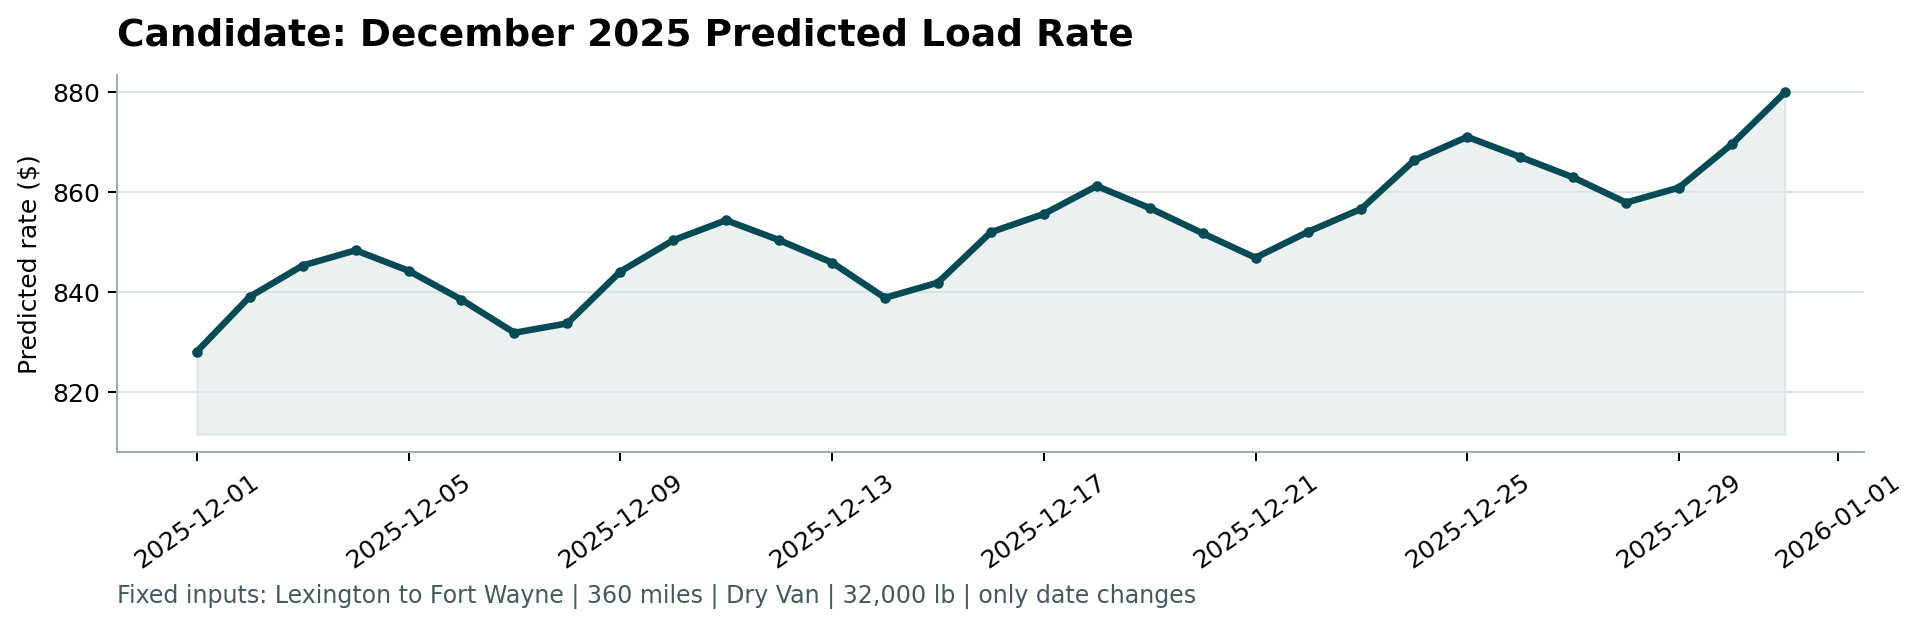

In [18]:
from IPython.display import Image
Image(f"{BASE}/scorer_results/candidate_december.png")